# Chapter 3b -- Pastor-Stambaugh, Pedersen-Fitzgibbons-Pomorski, and tracking error

Covers ESG asset-pricing models and tracking-error-constrained
portfolios (Roncalli, *Handbook of Sustainable Finance*).

Continues [`03a_esg_risk_and_factors.ipynb`](03a_esg_risk_and_factors.ipynb),
which covers the ESG-and-cost-of-debt illustrations, factor-model
covariance structures, and a Markowitz mean-variance review that this
notebook's models build directly on (risk aversion `gamma`, the tangency
portfolio, beta/pi/alpha decomposition). Performance measurement (bond/
equity indices, backtests, sorted-portfolio analysis) is planned for
`03c`.

Like `03a`, every example here is self-contained -- hardcoded
illustrative parameters, no external data files -- and the core
optimization already exists in `quanttoolbox`:
`quanttoolbox.sustainable_finance.esg.pedersen_portfolio` and
`quanttoolbox.portfolio.tracking_error`. The
Pastor-Stambaugh model itself has no dedicated toolbox function --
it's built directly from
`quanttoolbox.portfolio.mean_variance.mvo_portfolio` by tilting the
expected-return vector, so that part is implemented inline here.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from quanttoolbox.portfolio.mean_variance import mvo_portfolio, mvo_target_portfolio
from quanttoolbox.portfolio.tracking_error import te_frontier, te_target_portfolio
from quanttoolbox.sustainable_finance.esg import pedersen_portfolio

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


from quanttoolbox.linalg.special_matrices import xpnd


def corr_from_lower_triangle(values, n):
    # Thin wrapper around quanttoolbox's own xpnd (row-major half-vectorization
    # inverse, method=1), which builds exactly this matrix from a lower-triangular
    # (including diagonal) row-major listing.
    return xpnd(values, method=1)

## 1. The Pastor-Stambaugh taste-for-sustainability model

Pastor, Stambaugh & Taylor (2021, 2022): investors have a taste for
holding green assets, so a stock's expected return is tilted by its
"greenness" $g_i$ on top of its CAPM-implied premium. Mechanically, this
notebook implements the tilt as $\mu' = \mu + \psi\, g$ (or, viewed at a
specific risk aversion, $\mu' = \mu + \gamma\varphi\, g$) fed straight
into `mvo_portfolio` -- no new optimizer, just a different expected-return
input.


### 1.1 A small ESG tilt on a six-asset portfolio

Six assets with alternating greenness scores
($g_i = \pm 1\%$). First, the baseline portfolio at a $20\%$ volatility
target with no ESG tilt ($\varphi=0$) fixes the market risk aversion
$\gamma_1$; then, holding $\gamma_1$ fixed, the tilt strength $\varphi$
is increased and the portfolio re-optimized on $\mu' = \mu + \gamma_1
\varphi\, g$.


In [2]:
def pastor_params(n, rho=0.25, r=0.03, SR=0.20, g=None):
    i = np.arange(1, n + 1)
    Sigma_corr = np.full((n, n), rho)
    np.fill_diagonal(Sigma_corr, 1.0)
    sigma = 0.10 + 0.20 * np.exp(-np.ceil(i / 2) / n)
    Sigma = Sigma_corr * np.outer(sigma, sigma)
    mu = r + SR * sigma
    return mu, sigma, Sigma, r


n = 6
mu, sigma, Sigma, r = pastor_params(n)
g = 0.01 * np.tile([1, -1], n // 2)

baseline = mvo_target_portfolio(mu, Sigma, 0.20, problem="sigma", lb=0.0, ub=1.0)[0]
gamma1 = baseline.gamma

rows = [{"varphi": 0.0, **{f"A{i+1}": 100 * w for i, w in enumerate(baseline.weights)},
         "mu (%)": 100 * baseline.expected_return, "sigma (%)": 100 * baseline.volatility,
         "SR": (baseline.expected_return - r) / baseline.volatility}]

for varphi in [0.01, 0.05, 0.50]:
    b = varphi * g
    mu_prime = mu + gamma1 * b
    port = mvo_portfolio(mu_prime, Sigma, gamma=gamma1, lb=0.0, ub=1.0)
    mu_x, sigma_x = port.weights @ mu, np.sqrt(port.weights @ Sigma @ port.weights)
    rows.append({"varphi": 100 * varphi, **{f"A{i+1}": 100 * w for i, w in enumerate(port.weights)},
                 "mu (%)": 100 * mu_x, "sigma (%)": 100 * sigma_x, "SR": (mu_x - r) / sigma_x})

print(f"Market risk aversion at 20% vol target: gamma1 = {gamma1:.3f}")
pd.DataFrame(rows).round(3)


Market risk aversion at 20% vol target: gamma1 = 4.609


,varphi,A1,A2,A3,A4,A5,A6,mu (%),sigma (%),SR
0,0.0,44.967,44.967,5.033,5.033,0.0,0.0,8.334,20.000,0.267
1,1.0,48.872,41.062,9.817,0.250,-0.0,-0.0,8.334,20.092,0.265
2,5.0,58.649,19.600,21.751,0.000,-0.0,0.0,8.273,20.069,0.263
3,50.0,67.476,-0.000,32.524,0.000,0.0,0.0,8.217,21.557,0.242


### 1.2 The same idea, with a heterogeneous greenness vector

Same construction, but the six assets now have
distinct (all-positive) greenness scores instead of a simple $\pm 1\%$
alternation, and smaller tilt strengths since the greenness scores
themselves are larger.


In [3]:
n = 6
mu, sigma, Sigma, r = pastor_params(n)
g = np.array([0.1, 0.05, 0.02, 0.03, 0.25, 0.3])

baseline = mvo_target_portfolio(mu, Sigma, 0.20, problem="sigma", lb=0.0, ub=1.0)[0]
gamma1 = baseline.gamma

rows = [{"varphi": 0.0, **{f"A{i+1}": 100 * w for i, w in enumerate(baseline.weights)},
         "mu (%)": 100 * baseline.expected_return, "sigma (%)": 100 * baseline.volatility,
         "SR": (baseline.expected_return - r) / baseline.volatility}]

for varphi in [0.005, 0.01, 0.02]:
    b = varphi * g
    mu_prime = mu + gamma1 * b
    port = mvo_portfolio(mu_prime, Sigma, gamma=gamma1, lb=0.0, ub=1.0)
    mu_x, sigma_x = port.weights @ mu, np.sqrt(port.weights @ Sigma @ port.weights)
    rows.append({"varphi": 100 * varphi, **{f"A{i+1}": 100 * w for i, w in enumerate(port.weights)},
                 "mu (%)": 100 * mu_x, "sigma (%)": 100 * sigma_x, "SR": (mu_x - r) / sigma_x})

pd.DataFrame(rows).round(3)


,varphi,A1,A2,A3,A4,A5,A6,mu (%),sigma (%),SR
0,0.0,44.967,44.967,5.033,5.033,0.000,0.000,8.334,20.000,0.267
1,0.5,46.827,37.065,-0.000,-0.000,0.826,15.282,8.231,19.330,0.271
2,1.0,28.691,9.166,0.000,-0.000,16.616,45.527,7.789,16.703,0.287
3,2.0,0.000,0.000,0.000,0.000,21.089,78.911,7.426,19.170,0.231


### 1.3 The ESG-tilted efficient frontier, at scale

A 20-asset universe; at each point along a
risk-aversion sweep, the ESG tilt is scaled by that same point's own
$\gamma$ (so $\mu' = \mu + \gamma\varphi\, g$ varies smoothly with risk
aversion), for four tilt strengths $\varphi \in \{0, 0.5, 2, 10\}$. The
strongest tilts destabilize the low-risk-aversion end of the frontier
(long-only weights can't absorb an arbitrarily large ESG tilt at low
$\gamma$), so those segments are masked out rather than plotted.


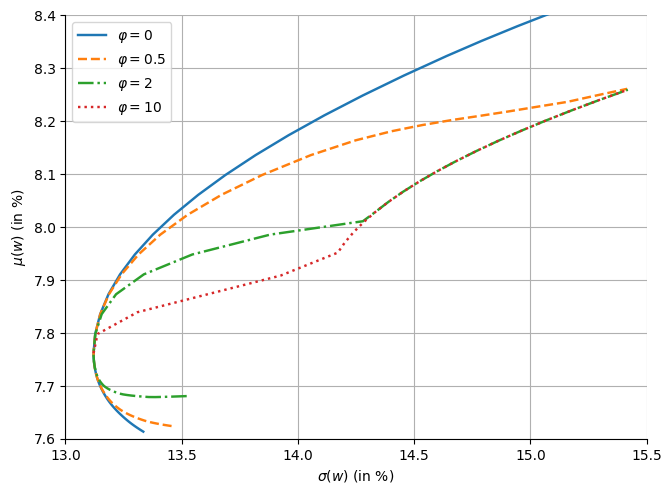

In [4]:
n = 20
mu, sigma, Sigma, r = pastor_params(n)
g = 0.01 * np.tile([1, -1], n // 2)

gammas = np.concatenate([np.arange(-0.50, 0, 0.01), np.arange(0, 1.0 + 0.05, 0.05)])


def tilted_frontier(varphi, mask_below=None):
    b = varphi * g
    mu_x = np.full_like(gammas, np.nan)
    sigma_x = np.full_like(gammas, np.nan)
    for it, gam in enumerate(gammas):
        mu_prime = mu + gam * b
        port = mvo_portfolio(mu_prime, Sigma, gamma=float(gam), lb=0.0, ub=1.0)
        mu_x[it] = port.weights @ mu
        sigma_x[it] = np.sqrt(port.weights @ Sigma @ port.weights)
    if mask_below is not None:
        sigma_x[gammas < mask_below] = np.nan
    return mu_x, sigma_x


mu_x1, sigma_x1 = tilted_frontier(0.0)
mu_x2, sigma_x2 = tilted_frontier(0.5)
mu_x3, sigma_x3 = tilted_frontier(2.0, mask_below=-0.30)
mu_x4, sigma_x4 = tilted_frontier(10.0, mask_below=0.0)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for (s, m), ls, lbl in zip([(sigma_x1, mu_x1), (sigma_x2, mu_x2), (sigma_x3, mu_x3), (sigma_x4, mu_x4)],
                            ["-", "--", "-.", ":"],
                            [r"$\varphi=0$", r"$\varphi=0.5$", r"$\varphi=2$", r"$\varphi=10$"]):
    ax.plot(100 * s, 100 * m, ls, lw=1.75, label=lbl)
ax.set_xlabel(r"$\sigma(w)$ (in %)")
ax.set_ylabel(r"$\mu(w)$ (in %)")
ax.set_xlim(13, 15.5)
ax.set_ylim(7.6, 8.4)
ax.grid(True)
ax.legend(fontsize=10)
plt.show()


### 1.4 Unaware vs. aware investors, and the aggregate market

Two investor types share the same universe:
an "unaware" investor who ignores ESG entirely ($\varphi=0$, portfolio
$x_1$), and an "aware" investor who fully applies the tilt
($\varphi=1$, portfolio $x_2$), both at the same risk aversion
$\gamma_m$ implied by the CAPM tangency portfolio. If unaware and aware
capital are equally split ($W_1=W_2$), the aggregate market portfolio is
$x_3 = 0.5 x_1 + 0.5 x_2$. Each portfolio's assets are then
beta-decomposed against *that portfolio itself* as the pricing
benchmark: $\beta_i = (\Sigma x)_i / (x^\top \Sigma x)$, $\pi_i =
\beta_i(\mu(x)-r)$, $\alpha_i = (\mu_i - r) - \pi_i$ -- the CAPM-implied
premium and the residual "mispricing" each portfolio's asset prices
imply.


In [5]:
def beta_pi_alpha(x, mu, Sigma, r):
    mu_x = x @ mu
    sigma_x = np.sqrt(x @ Sigma @ x)
    beta_x = (Sigma @ x) / sigma_x**2
    pi_x = beta_x * (mu_x - r)
    alpha_x = (mu - r) - pi_x
    return mu_x, sigma_x, beta_x, pi_x, alpha_x


n = 6
mu, sigma, Sigma, r = pastor_params(n)
g = 0.01 * np.tile([1, -1], n // 2)

x_m = np.linalg.solve(Sigma, mu - r)
gamma_m = 1.0 / x_m.sum()
x_m = x_m / x_m.sum()

x1 = mvo_portfolio(mu, Sigma, gamma=gamma_m, lb=0.0, ub=1.0).weights
mu_x1, sigma_x1, beta_x1, pi_x1, alpha_x1 = beta_pi_alpha(x1, mu, Sigma, r)

b = 1.0 * g
x2 = mvo_portfolio(mu + gamma_m * b, Sigma, gamma=gamma_m, lb=0.0, ub=1.0).weights
mu_x2, sigma_x2, beta_x2, pi_x2, alpha_x2 = beta_pi_alpha(x2, mu, Sigma, r)

x3 = 0.5 * x1 + 0.5 * x2
mu_x3, sigma_x3, beta_x3, pi_x3, alpha_x3 = beta_pi_alpha(x3, mu, Sigma, r)

pd.DataFrame({
    "x_market": 100 * x_m,
    "unaware x1": 100 * x1, "beta(x1)": beta_x1, "pi(x1) (%)": 100 * pi_x1,
    "aware x2": 100 * x2, "beta(x2)": beta_x2, "pi(x2) (%)": 100 * pi_x2, "alpha(x2) (bps)": 1e4 * alpha_x2,
    "aggregate x3": 100 * x3, "beta(x3)": beta_x3, "pi(x3) (%)": 100 * pi_x3, "alpha(x3) (bps)": 1e4 * alpha_x3,
}).round(3)


,x_market,unaware x1,beta(x1),pi(x1) (%),aware x2,beta(x2),pi(x2) (%),alpha(x2) (bps),aggregate x3,beta(x3),pi(x3) (%),alpha(x3) (bps)
0,15.044,15.044,1.108,5.386,18.863,1.171,5.691,-30.475,16.953,1.147,5.577,-19.088
1,15.044,15.044,1.108,5.386,11.225,0.988,4.803,58.320,13.134,1.054,5.124,26.187
2,16.651,16.651,1.001,4.866,21.329,1.066,5.184,-31.819,18.990,1.041,5.060,-19.431
3,16.651,16.651,1.001,4.866,11.972,0.884,4.296,56.977,14.311,0.948,4.608,25.845
4,18.306,18.306,0.910,4.426,23.961,0.978,4.756,-32.956,21.133,0.951,4.623,-19.721
5,18.306,18.306,0.910,4.426,12.651,0.796,3.868,55.839,15.478,0.858,4.171,25.555


### 1.5 The greenium as a function of ESG-investor market share

Continuing the previous setup, but now sweeping
the aggregate market's ESG-aware share $\omega^{\text{esg}} = W_2/(W_1+W_2)$
from $0$ to (almost) $100\%$, and tracking $\alpha_3 = \pi(x_1) -
\pi(x_2^{\text{aggregate}})$ -- how much the CAPM-implied premium of each
asset shifts, per asset, purely as a function of how large a share of
the market applies the ESG tilt. This is the model's central result: an
ESG "greenium" that emerges endogenously from aggregate investor
demand, without assuming it directly.


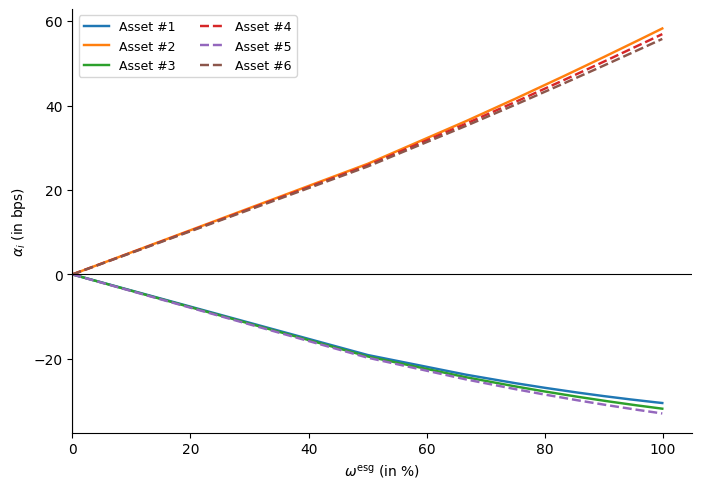

In [6]:
n_iters = 1000
omega = np.zeros(n_iters)
pi_esg = np.zeros((n_iters, n))

for it in range(n_iters):
    W1, W2 = 1.0, float(it)
    omega2 = W2 / (W1 + W2)
    x3 = (1 - omega2) * x1 + omega2 * x2
    _, _, _, pi_x3, _ = beta_pi_alpha(x3, mu, Sigma, r)
    omega[it] = omega2
    pi_esg[it, :] = pi_x1 - pi_x3

fig, ax = plt.subplots(figsize=(8, 5.5))
for i in range(n):
    ax.plot(100 * omega, 1e4 * pi_esg[:, i], "-" if i < 3 else "--", lw=1.75, label=f"Asset #{i+1}")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(r"$\omega^{\mathrm{esg}}$ (in %)")
ax.set_ylabel(r"$\alpha_i$ (in bps)")
ax.set_xlim(0, 105)
ax.legend(fontsize=9, ncol=2)
plt.show()


### 1.6 How long would it take to detect an alpha this size?

If two assets have "true" idiosyncratic
volatility $\tilde\sigma_1=\tilde\sigma_2=10\%$ each, the volatility of
their *return difference* is $\sigma=\sqrt{\tilde\sigma_1^2+
\tilde\sigma_2^2}$. Given a true (constant) return difference $\Delta
\alpha$, the probability of a $t$-year sample correctly detecting a
positive difference is $p_u(\Delta\alpha, t) = \Phi\!\left(\dfrac{\Delta
\alpha \sqrt{t}}{\sigma}\right)$; inverting for the horizon needed to
hit a target detection probability $p_u$ gives $t(\Delta\alpha, p_u) =
\left(\dfrac{\sigma}{\Delta\alpha}\,\Phi^{-1}(p_u)\right)^2$. A
diversified $n=1000$-asset portfolio-level version divides $\sigma$ by
$\sqrt{n}$ -- diversification makes a given alpha far easier to detect.


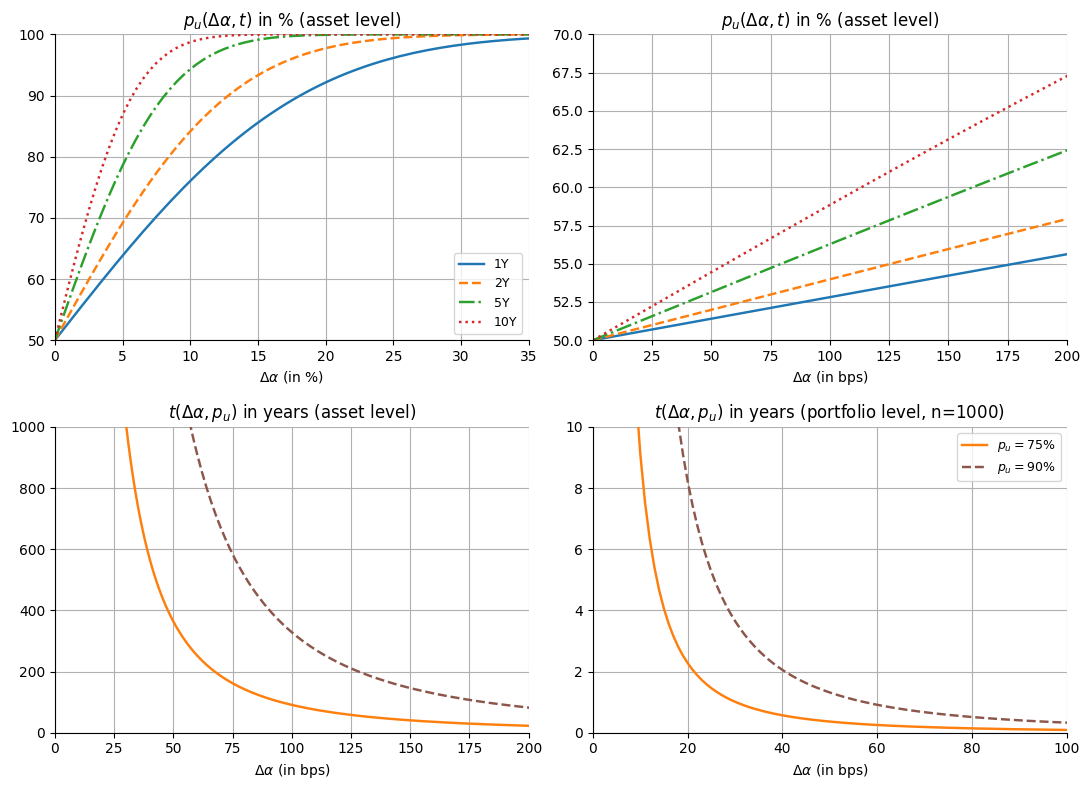

In [7]:
sigma_tilde1 = sigma_tilde2 = 0.10
sigma_diff = np.sqrt(sigma_tilde1**2 + sigma_tilde2**2)

delta_alpha = np.concatenate([np.arange(0, 201), np.arange(200, 5001, 50)]) / 1e4
horizons = [1, 2, 5, 10]
p = np.column_stack([stats.norm.cdf(delta_alpha * np.sqrt(t) / sigma_diff) for t in horizons])

confidence = [0.75, 0.90]
# delta_alpha starts at 0 (detecting a zero difference takes an infinite
# horizon by construction) -- an expected /0 -> inf, not a bug.
with np.errstate(divide="ignore"):
    t_asset = np.column_stack([(sigma_diff / delta_alpha * stats.norm.ppf(a)) ** 2 for a in confidence])
    n_portfolio = 1000
    t_portfolio = np.column_stack([(sigma_diff / np.sqrt(n_portfolio) / delta_alpha * stats.norm.ppf(a)) ** 2
                                    for a in confidence])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
for i, t in enumerate(horizons):
    ax.plot(1e2 * delta_alpha, 100 * p[:, i], ["-", "--", "-.", ":"][i], lw=1.75, label=f"{t}Y")
ax.set_xlabel(r"$\Delta\alpha$ (in %)")
ax.set_title(r"$p_u(\Delta\alpha, t)$ in % (asset level)")
ax.set_xlim(0, 35)
ax.set_ylim(50, 100)
ax.grid(True)
ax.legend(fontsize=9)

ax = axes[0, 1]
for i, t in enumerate(horizons):
    ax.plot(1e4 * delta_alpha, 100 * p[:, i], ["-", "--", "-.", ":"][i], lw=1.75)
ax.set_xlabel(r"$\Delta\alpha$ (in bps)")
ax.set_title(r"$p_u(\Delta\alpha, t)$ in % (asset level)")
ax.set_xlim(0, 200)
ax.set_ylim(50, 70)
ax.grid(True)

ax = axes[1, 0]
for i, a in enumerate(confidence):
    ax.plot(1e4 * delta_alpha, t_asset[:, i], ["-", "--"][i], lw=1.75, color=["tab:orange", "tab:brown"][i])
ax.set_xlabel(r"$\Delta\alpha$ (in bps)")
ax.set_title(r"$t(\Delta\alpha, p_u)$ in years (asset level)")
ax.set_xlim(0, 200)
ax.set_ylim(0, 1000)
ax.grid(True)

ax = axes[1, 1]
for i, a in enumerate(confidence):
    ax.plot(1e4 * delta_alpha, t_portfolio[:, i], ["-", "--"][i], lw=1.75, color=["tab:orange", "tab:brown"][i],
            label=f"$p_u={int(100*a)}\\%$")
ax.set_xlabel(r"$\Delta\alpha$ (in bps)")
ax.set_title(r"$t(\Delta\alpha, p_u)$ in years (portfolio level, n=1000)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 10)
ax.grid(True)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 1.7 Four ways to price ESG: CAPM, tangency, PST, and ACLT

A four-asset universe with both a return-based
ESG signal ($\mu_{\text{esg}}$) and its own risk
($\Sigma_{\text{esg}} = \tilde\sigma_{\text{esg}}^2 I$), compared across
four constructions, each decomposed into $\beta$/$\pi$/$\alpha$ relative
to the plain-CAPM benchmark $x_0$:

- **CAPM** ($x_0$): the ordinary tangency portfolio, $x_0 \propto
  \Sigma^{-1}(\mu-r)$ -- the pricing benchmark every $\alpha$ below is
  measured against.
- **Tangency** ($x_1$): re-solved via `mvo_portfolio` at the CAPM-implied
  risk aversion $\gamma_m$ -- a numerical cross-check that reproduces
  $x_0$.
- **PST** ($x_2$, Pastor-Stambaugh-Taylor): tilts only the expected
  return, $\mu' = \mu + \psi\,\mu_{\text{esg}}$ with $\psi = \gamma_m
  \varphi_{\text{esg}}$.
- **ACLT** ($x_3$, Avramov-Cheng-Lioui-Tarelli 2022): tilts *both* the
  expected return and the covariance, adding the ESG signal's own risk,
  $\Sigma' = \Sigma + \psi^2 \Sigma_{\text{esg}}$ -- a more conservative
  tilt that also accounts for the ESG signal's own uncertainty.


In [8]:
r = 0.02
mu = np.array([0.05, 0.06, 0.07, 0.08])
sigma = np.array([0.15, 0.20, 0.30, 0.30])
corr = corr_from_lower_triangle(
    [1.00,
     0.10, 1.00,
     0.40, 0.60, 1.00,
     0.50, 0.40, 0.80, 1.00], 4)
Sigma = corr * np.outer(sigma, sigma)
n = len(mu)

mu_esg = np.array([0.03, -0.02, 0.01, -0.01])
Sigma_esg = 0.20**2 * np.eye(n)
varphi_esg = 0.50

x0 = np.linalg.solve(Sigma, mu - r)
gamma_m = 1.0 / x0.sum()
x0 = x0 / x0.sum()
mu_x0, sigma_x0, beta_x0, pi_x0, alpha_x0 = beta_pi_alpha(x0, mu, Sigma, r)

x1 = mvo_portfolio(mu, Sigma, gamma=gamma_m, lb=0.0, ub=1.0).weights
mu_x1, sigma_x1, beta_x1, pi_x1, alpha_x1 = beta_pi_alpha(x1, mu, Sigma, r)

psi = gamma_m * varphi_esg
mu_prime = mu + psi * mu_esg
x2 = mvo_portfolio(mu_prime, Sigma, gamma=gamma_m, lb=0.0, ub=1.0).weights
mu_x2, sigma_x2, beta_x2, pi_x2, alpha_x2 = beta_pi_alpha(x2, mu, Sigma, r)

Sigma_prime = Sigma + psi**2 * Sigma_esg
x3 = mvo_portfolio(mu_prime, Sigma_prime, gamma=gamma_m, lb=0.0, ub=1.0).weights
mu_x3, sigma_x3, beta_x3, pi_x3, alpha_x3 = beta_pi_alpha(x3, mu, Sigma, r)

pd.DataFrame({
    "CAPM x0": 100 * x0, "Tangency x1": 100 * x1, "PST x2": 100 * x2, "ACLT x3": 100 * x3,
})


,CAPM x0,Tangency x1,PST x2,ACLT x3
0,50.078641,5.200187e+01,6.402854e+01,6.186614e+01
1,48.977666,3.964700e+01,3.150612e+01,3.204658e+01
2,-22.522806,-9.806544e-22,1.138776e-21,-4.121539e-21
3,23.466499,8.351127e+00,4.465341e+00,6.087284e+00


In [9]:
pd.DataFrame({
    "mu (%)": [100 * mu_x0, 100 * mu_x1, 100 * mu_x2, 100 * mu_x3],
    "sigma (%)": [100 * sigma_x0, 100 * sigma_x1, 100 * sigma_x2, 100 * sigma_x3],
    "mean alpha (bps)": [1e4 * alpha_x0.mean(), 1e4 * alpha_x1.mean(), 1e4 * alpha_x2.mean(), 1e4 * alpha_x3.mean()],
}, index=["CAPM", "Tangency", "PST", "ACLT"]).round(3)


,mu (%),sigma (%),mean alpha (bps)
CAPM,5.743,13.199,-0.000
Tangency,5.647,13.334,-24.689
PST,5.449,12.863,12.160
ACLT,5.503,12.990,0.888


## 2. The Pedersen-Fitzgibbons-Pomorski ESG-efficient frontier

Pedersen, Fitzgibbons & Pomorski (2021): rather than tilting expected
returns, directly constrain the portfolio's *ESG score* alongside its
volatility, tracing out a full "ESG-efficient frontier" (Sharpe ratio
vs. ESG-score target) instead of a single tilted portfolio. Uses
`quanttoolbox.sustainable_finance.esg.pedersen_portfolio` directly.


### 2.1-2.2 A single ESG-efficient portfolio

Solve for the portfolio
that hits a target volatility $\bar\sigma$ and a target ESG score
$\bar{\mathbf{S}}$ exactly, for two different target pairs.


In [10]:
r = 0.02
mu = np.array([0.06, 0.07, 0.08, 0.10])
sigma = np.array([0.15, 0.20, 0.25, 0.30])
corr = corr_from_lower_triangle(
    [1.00,
     0.20, 1.00,
     0.30, 0.50, 1.00,
     0.40, 0.60, 0.70, 1.00], 4)
Sigma = corr * np.outer(sigma, sigma)
S = np.array([0.03, 0.02, -0.02, -0.03])


def summarise_pedersen(res, label):
    w = res.w[:, 0]
    print(f"--- {label} ---")
    print("C_x_y (C_1pi, C_Spi, C_SS, C_1S, C_11, C_pipi):", np.round(res.c_x_y, 4))
    print(f"lambda1={res.lambda1[0]:.4f}, lambda2={res.lambda2[0]:.4f}")
    display(pd.Series({f"A{i+1}": round(100 * wi, 2) for i, wi in enumerate(w)}, name="weight (%)"))
    print(f"cash weight: {100*res.w_r[0]:.2f}%")
    print(f"pi(w)={100*res.pi_w[0]:.2f}%  sigma(w)={100*res.sigma_w[0]:.2f}%  S(w)={100*res.s_w[0]:.2f}%")
    print(f"SR(w) = {res.sr_w[0, 0]:.4f}")


res1 = pedersen_portfolio(mu, r, Sigma, S, sigma_bar=0.20, s_bar=0.01)
summarise_pedersen(res1, "pedersen1: sigma_bar=20%, S_bar=1%")


--- pedersen1: sigma_bar=20%, S_bar=1% ---
C_x_y (C_1pi, C_Spi, C_SS, C_1S, C_11, C_pipi): [2.48640e+00 4.25000e-02 1.27400e-01 1.98010e+00 6.41106e+01 1.19300e-01]
lambda1=-0.8514, lambda2=-0.1870


A1    59.31
A2    29.52
A3    21.76
A4    20.72
Name: weight (%), dtype: float64

cash weight: -31.31%
pi(w)=6.81%  sigma(w)=20.00%  S(w)=1.00%
SR(w) = 0.3406


In [11]:
res2 = pedersen_portfolio(mu, r, Sigma, S, sigma_bar=0.10, s_bar=0.00)
summarise_pedersen(res2, "pedersen2: sigma_bar=10%, S_bar=0%")
rho_S = res2.w[:, 0] / 0.10
print(f"1 / sum(w/sigma_bar) = {1/rho_S.sum():.4f}")


--- pedersen2: sigma_bar=10%, S_bar=0% ---
C_x_y (C_1pi, C_Spi, C_SS, C_1S, C_11, C_pipi): [2.48640e+00 4.25000e-02 1.27400e-01 1.98010e+00 6.41106e+01 1.19300e-01]
lambda1=-1.6211, lambda2=-0.3334


A1    19.59
A2     7.84
A3    12.26
A4    16.64
Name: weight (%), dtype: float64

cash weight: 43.67%
pi(w)=3.24%  sigma(w)=10.00%  S(w)=-0.00%
SR(w) = 0.3242
1 / sum(w/sigma_bar) = 0.1775


### 2.3 The cost of an ESG constraint: Sharpe ratio vs. ESG-score target

Sweeping the ESG-score target $\bar{\mathbf{S}}$
at a fixed volatility target ($\bar\sigma=20\%$) traces out the
"ESG-efficient frontier": the achievable Sharpe ratio as a function of
how aggressive an ESG target is imposed. It peaks at the unconstrained
optimum and falls away on either side -- the further the ESG target from
what the assets would deliver anyway, the more Sharpe ratio is given up.


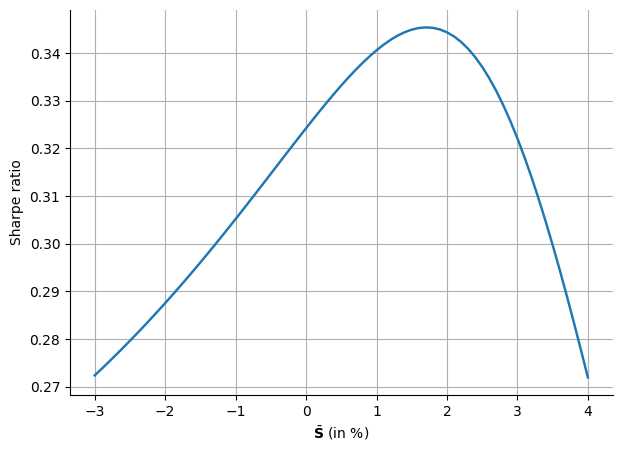

In [12]:
s_grid = np.arange(-3, 4.01, 0.1) / 100
res = pedersen_portfolio(mu, r, Sigma, S, sigma_bar=0.20, s_bar=s_grid)
all_SR = res.sr_w[:, 0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * s_grid, all_SR, "-", lw=1.75)
ax.set_xlabel(r"$\bar{\mathbf{S}}$ (in %)")
ax.set_ylabel("Sharpe ratio")
ax.grid(True)
plt.show()


### 2.4 The unconstrained tangency portfolio vs. the best point on the ESG-efficient frontier

Two views of the same
comparison: the ordinary (ESG-unaware) tangency portfolio $w_U$ sits
at some ESG score $\mathbf{S}(w_U)$ on the Sharpe-ratio-vs-ESG-target
curve from the section above; the point $w_A$ that actually *maximises*
Sharpe ratio along that curve is found by a fine grid search, and its
own ESG-score / Sharpe-ratio pair is marked. If $w_U$ already sits at
the curve's peak, ESG constraints of this kind are free; otherwise there
is a genuine Sharpe-ratio cost to imposing $w_U$'s own ESG score as a
hard target versus the best achievable one.


w_U: pi=4.80%, sigma=13.89%, S=1.71%, SR=0.3454
w_A: pi=3.45%, sigma=10.00%, S=1.71%, SR=0.3454


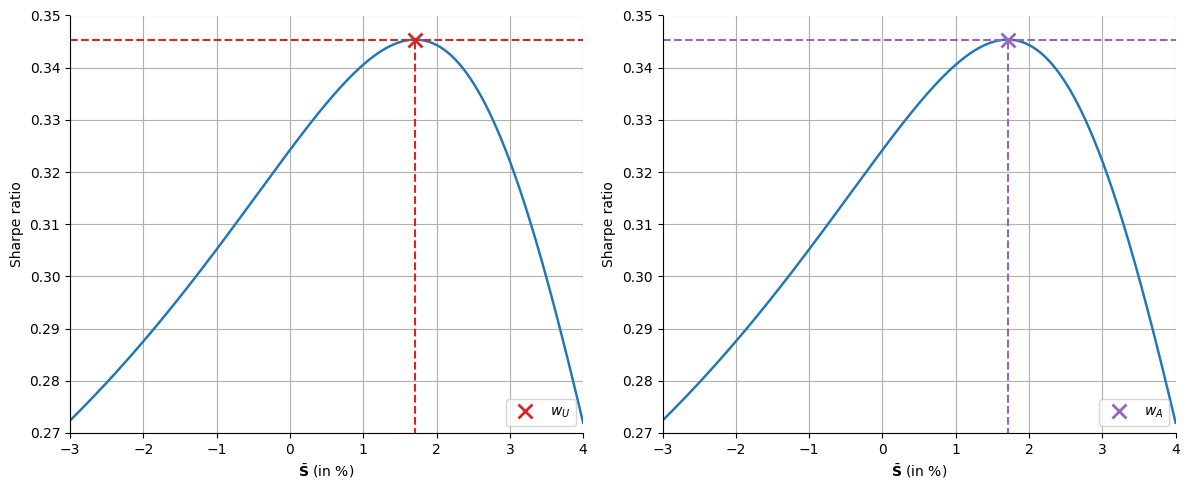

In [13]:
inv_Sigma = np.linalg.inv(Sigma)
pi_ = mu - r

w_U = inv_Sigma @ pi_
w_U = w_U / w_U.sum()
pi_U = w_U @ pi_
sigma_U = np.sqrt(w_U @ Sigma @ w_U)
SR_U = pi_U / sigma_U
S_U = w_U @ S

s_grid = np.arange(-3, 4.01, 0.01) / 100
res = pedersen_portfolio(mu, r, Sigma, S, sigma_bar=0.10, s_bar=s_grid)
all_SR = res.sr_w[:, 0]
i_max = int(np.argmax(all_SR))
S_A, SR_A = s_grid[i_max], all_SR[i_max]
w_A = res.w[:, i_max]
sigma_A = res.sigma_w[i_max]

print(f"w_U: pi={100*pi_U:.2f}%, sigma={100*sigma_U:.2f}%, S={100*S_U:.2f}%, SR={SR_U:.4f}")
print(f"w_A: pi={100*res.pi_w[i_max]:.2f}%, sigma={100*sigma_A:.2f}%, S={100*S_A:.2f}%, SR={SR_A:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (mark_x, mark_y, mark_lbl, colour) in zip(
        axes, [(S_U, SR_U, "$w_U$", "tab:red"), (S_A, SR_A, "$w_A$", "tab:purple")]):
    ax.plot(100 * s_grid, all_SR, "-", color="tab:blue", lw=1.75)
    ax.plot(100 * s_grid, np.full_like(s_grid, mark_y), "--", color=colour, lw=1.5)
    ax.plot([100 * mark_x] * 2, [0, mark_y], "--", color=colour, lw=1.5)
    ax.plot(100 * mark_x, mark_y, "x", color=colour, markersize=10, mew=2, label=mark_lbl)
    ax.set_xlabel(r"$\bar{\mathbf{S}}$ (in %)")
    ax.set_ylabel("Sharpe ratio")
    ax.set_xlim(-3, 4)
    ax.set_ylim(0.27, 0.35)
    ax.grid(True)
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### 2.5 Choosing an ESG target under an explicit greenness preference

Instead of maximizing
Sharpe ratio alone, an investor with risk aversion $\bar\gamma$ and
greenness preference maximizes $\xi(\bar{\mathbf{S}}) =
\mathrm{SR}(\bar{\mathbf{S}})^2 + 2\bar\gamma\,\zeta(\bar{\mathbf{S}})$
for some greenness-utility function $\zeta$. Two shapes are compared:
a linear $\zeta(s)=s$ (more ESG is always better, at a
constant rate) and a concave $\zeta(s) = 0.2\sqrt{s}\,
\mathbb{1}\{s>0\}$ (only positive ESG scores are rewarded, with
diminishing returns) -- the more greenness-averse (high $\bar\gamma$)
the investor, the further the optimal target shifts from the pure-Sharpe
optimum.


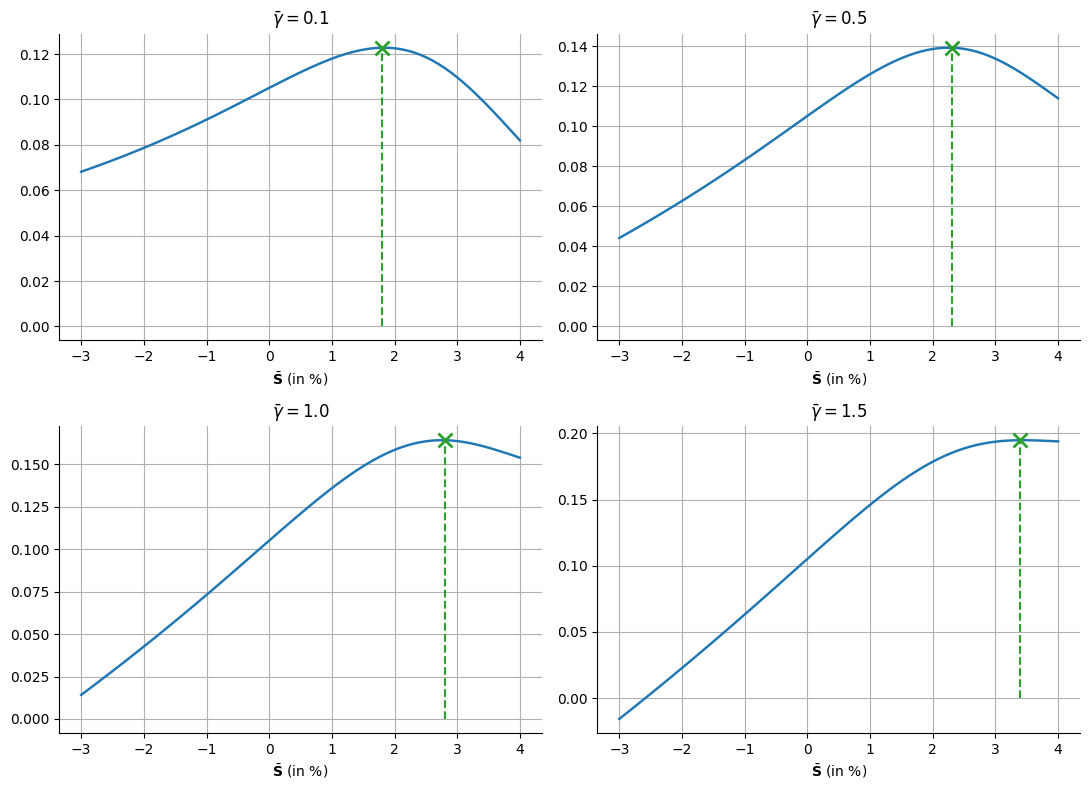

,gamma_bar,S_bar (%),sigma_bar (%),SR,A1 (%),A2 (%),A3 (%),A4 (%)
0,0.1,1.8,345.279,0.345,1339.639,745.978,283.916,141.226
1,0.5,2.3,68.179,0.341,302.752,178.584,38.265,-1.167
2,1.0,2.8,32.904,0.329,162.321,100.892,7.301,-14.361
3,1.5,3.4,20.315,0.305,108.950,71.845,-5.603,-17.798


In [14]:
def greenness_utility_optima(zeta, s_grid_bp=0.1):
    s_grid = np.arange(-3, 4.01, s_grid_bp) / 100
    res = pedersen_portfolio(mu, r, Sigma, S, sigma_bar=0.20, s_bar=s_grid)
    all_SR = res.sr_w[:, 0]
    gamma_bars = [0.1, 0.5, 1.0, 1.5]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    rows = []
    for ax, gamma_bar in zip(axes.ravel(), gamma_bars):
        xi = all_SR**2 + 2 * gamma_bar * zeta(s_grid)
        i_max = int(np.argmax(xi))
        SR_w, S_bar = all_SR[i_max], s_grid[i_max]
        sigma_bar = SR_w / gamma_bar

        point = pedersen_portfolio(mu, r, Sigma, S, sigma_bar=sigma_bar, s_bar=S_bar)
        rows.append({"gamma_bar": gamma_bar, "S_bar (%)": 100 * S_bar, "sigma_bar (%)": 100 * sigma_bar,
                      "SR": point.sr_w[0, 0], **{f"A{i+1} (%)": 100 * w for i, w in enumerate(point.w[:, 0])}})

        ax.plot(100 * s_grid, xi, "-", color="tab:blue", lw=1.75)
        ax.plot([100 * S_bar] * 2, [0, xi[i_max]], "--", color="tab:green")
        ax.plot(100 * S_bar, xi[i_max], "x", color="tab:green", markersize=10, mew=2)
        ax.set_xlabel(r"$\bar{\mathbf{S}}$ (in %)")
        ax.set_title(rf"$\bar\gamma = {gamma_bar}$")
        ax.grid(True)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows).round(3)


linear_results = greenness_utility_optima(lambda s: s)
linear_results


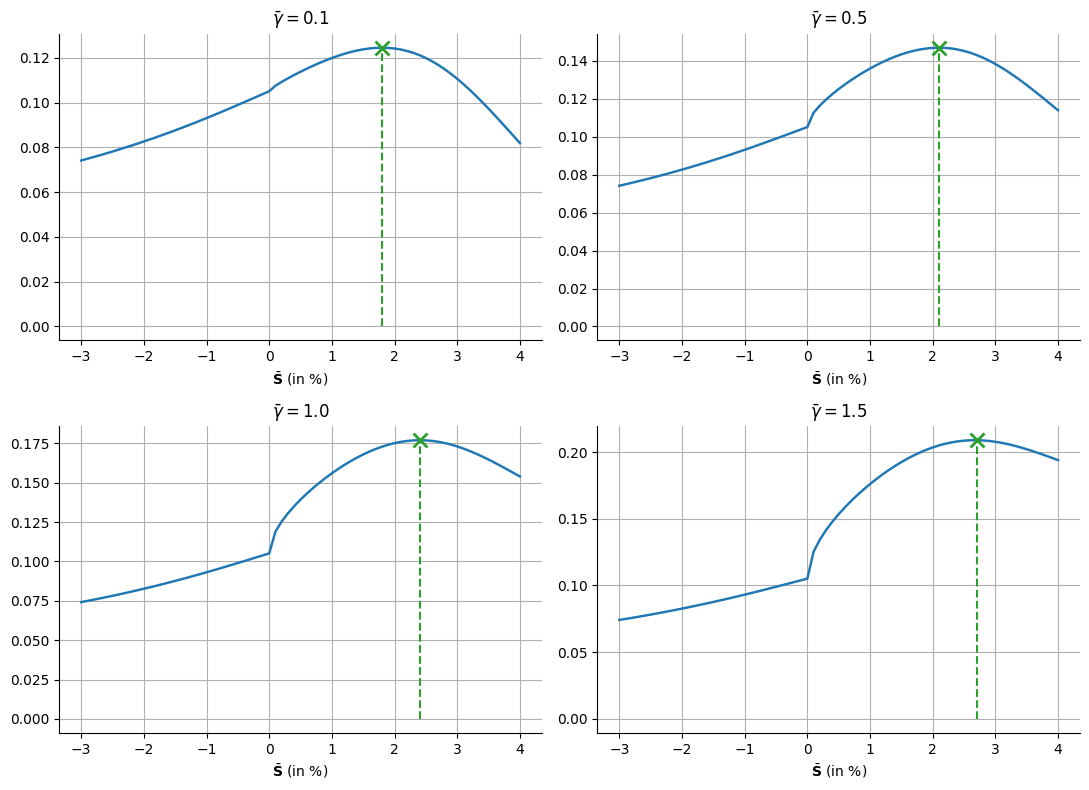

,gamma_bar,S_bar (%),sigma_bar (%),SR,A1 (%),A2 (%),A3 (%),A4 (%)
0,0.1,1.8,345.279,0.345,1339.639,745.978,283.916,141.226
1,0.5,2.1,68.696,0.343,289.993,167.295,46.378,10.611
2,1.0,2.4,33.915,0.339,154.188,91.938,16.942,-3.483
3,1.5,2.7,22.136,0.332,107.199,65.957,6.548,-7.857


In [15]:
concave_results = greenness_utility_optima(lambda s: 0.2 * np.sqrt(np.clip(s, 0, None)) * (s > 0))
concave_results


## 3. Tracking-error-constrained portfolios

Instead of an
absolute-return mean-variance problem, the portfolio is optimized
*relative to a benchmark* $b$: minimize tracking error while trading off
active return, using `quanttoolbox.portfolio.tracking_error`.


In [16]:
mu = np.array([0.05, 0.065, 0.08, 0.065])
sigma = np.array([0.15, 0.20, 0.25, 0.30])
corr = corr_from_lower_triangle(
    [1.00,
     0.10, 1.00,
     0.40, 0.70, 1.00,
     0.50, 0.40, 0.80, 1.00], 4)
Sigma = corr * np.outer(sigma, sigma)
b = np.array([0.60, 0.40, 0.20, -0.20])


### 3.1 The tracking-error frontier under three weight-constraint regimes

Active risk (tracking error) vs. active return, for
an unconstrained overlay, a modest short-selling allowance
($w_i \geq -10\%$), and asymmetric box constraints tailored per asset.


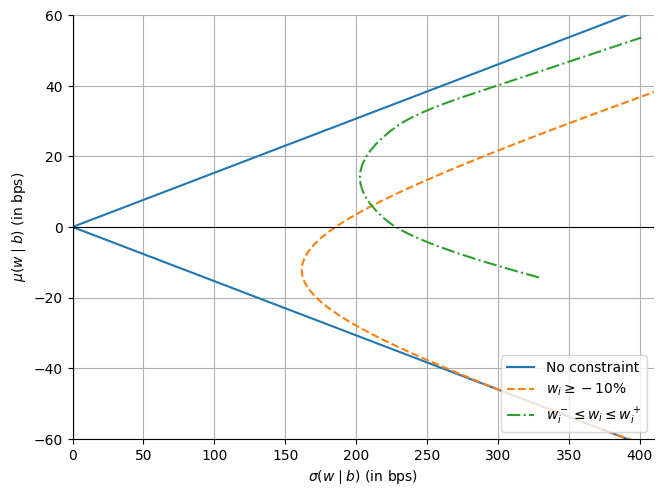

In [17]:
gammas = np.arange(-0.30, 0.30 + 0.01, 0.01)

regimes = {
    "No constraint": te_frontier(b, mu, Sigma, gammas, lb=-10.0, ub=10.0),
    r"$w_i \geq -10\%$": te_frontier(b, mu, Sigma, gammas, lb=-0.10, ub=10.0),
    r"$w_i^- \leq w_i \leq w_i^+$": te_frontier(
        b, mu, Sigma, gammas, lb=np.array([0.0, 0.0, 0.0, -0.20]), ub=np.array([0.5, 0.5, 0.5, 0.5])),
}

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for (label, pts), ls in zip(regimes.items(), ["-", "--", "-."]):
    te = np.array([p.tracking_error for p in pts])
    ar = np.array([p.active_return for p in pts])
    ax.plot(1e4 * te, 1e4 * ar, ls, lw=1.5, label=label)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(r"$\sigma(w \mid b)$ (in bps)")
ax.set_ylabel(r"$\mu(w \mid b)$ (in bps)")
ax.set_xlim(0, 410)
ax.set_ylim(-60, 60)
ax.grid(True)
ax.legend(fontsize=10, loc="lower right")
plt.show()


### 3.2 The maximum-information-ratio portfolio

Under the box-constrained regime, the point on the
tracking-error frontier with the highest information ratio
($\mathrm{IR} = \mu(w\mid b)/\sigma(w\mid b)$) defines an "active market
line" through the origin, the tracking-error analogue of the capital
market line -- compared here against the portfolio hitting a fixed
300bps tracking-error target directly.


Weights at max-IR point: [ 49.44  34.88  35.68 -20.  ]


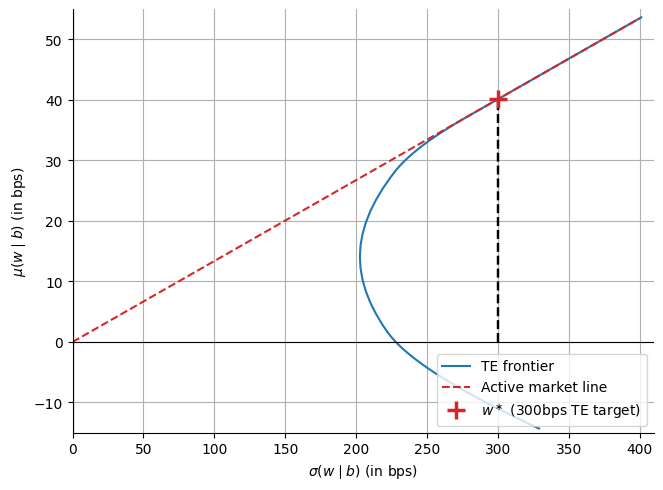

Max information ratio: 0.1337
300bps-TE-target portfolio: active return=40.1bps, gamma=0.2243


In [18]:
lb, ub = np.array([0.0, 0.0, 0.0, -0.20]), np.array([0.5, 0.5, 0.5, 0.5])

target = te_target_portfolio(b, mu, Sigma, 0.03, problem="sigma", lb=lb, ub=ub)[0]

gammas = np.arange(-0.30, 0.30 + 0.01, 0.01)
frontier = te_frontier(b, mu, Sigma, gammas, lb=lb, ub=ub)
te_arr = np.array([p.tracking_error for p in frontier])
ar_arr = np.array([p.active_return for p in frontier])
IR = ar_arr / te_arr
i_max = int(np.argmax(IR))
IR_max = IR[i_max]

print("Weights at max-IR point:", np.round(100 * frontier[i_max].weights, 2))

x_line = np.linspace(0, 1 / 25, 41)
y_line = IR_max * x_line

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(1e4 * te_arr, 1e4 * ar_arr, "-", color="tab:blue", lw=1.5, label="TE frontier")
ax.plot(1e4 * x_line, 1e4 * y_line, "--", color="tab:red", lw=1.5, label="Active market line")
ax.plot([1e4 * target.tracking_error] * 2, [0, 1e4 * target.active_return], "--", color="black", lw=1.75)
ax.plot(1e4 * target.tracking_error, 1e4 * target.active_return, "+", color="tab:red", markersize=13, mew=2.5,
        label=r"$w^\ast$ (300bps TE target)")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(r"$\sigma(w \mid b)$ (in bps)")
ax.set_ylabel(r"$\mu(w \mid b)$ (in bps)")
ax.set_xlim(0, 410)
ax.set_ylim(-15, 55)
ax.grid(True)
ax.legend(fontsize=10, loc="lower right")
plt.show()

print(f"Max information ratio: {IR_max:.4f}")
print(f"300bps-TE-target portfolio: active return={1e4*target.active_return:.1f}bps, gamma={target.gamma:.4f}")
